# 🎬 Movie Recommendation System
### Boosting engagement on a streaming platform with personalized recommendations

---

**Author:** Data Science Portfolio Project &nbsp;•&nbsp; **Dataset:** [MovieLens `ml-latest-small`](https://grouplens.org/datasets/movielens/) &nbsp;•&nbsp; **Domain:** Media / Streaming

> *The techniques below (popularity, content-based, collaborative filtering, matrix factorization, hybrid) are catalog-agnostic — the exact same pipeline powers **product** recommendations in e-commerce, music, and news.*

## 📌 Business Problem

A subscription streaming service lives and dies by **engagement**. Industry studies consistently attribute a large share of watch time to the recommendation surface — when users can't find something to watch, session length drops and churn rises. Our streaming client faces three concrete symptoms:

- **Choice overload** — a catalog of thousands of titles overwhelms users, who abandon the browse session before pressing play.
- **The long tail is invisible** — a handful of blockbusters dominate the home screen while thousands of relevant niche titles are never surfaced.
- **No personalization** — every user currently sees the same "Popular Now" row, regardless of taste.

## 🎯 Objective

Design, implement, and **rigorously evaluate** a recommendation engine that surfaces the *right* titles for each user, with the business goal of increasing **engagement** (click-through and watch-through on recommended items) and, downstream, **retention**.

Concretely, this notebook will:

1. Explore the interaction data to understand user behavior and catalog structure.
2. Build **five** recommender families of increasing sophistication, from a popularity baseline to a hybrid model.
3. Evaluate them with the metrics that actually matter for each task — **RMSE / MAE** for rating prediction and **Precision@K, Recall@K, NDCG@K** (plus catalog coverage) for the top-*N* ranking that users actually see.
4. Translate the model results into **business recommendations**.

## 📚 Dataset

**MovieLens `ml-latest-small`** (GroupLens Research) — a widely used academic benchmark that stands in for a streaming platform's interaction logs:

| File | Description |
|------|-------------|
| `ratings.csv` | ~100,000 ratings (0.5–5.0 stars) from ~610 users on ~9,700 movies |
| `movies.csv`  | Movie titles and pipe-separated genres |
| `tags.csv`    | Free-text tags users applied to movies (used for content features) |

The dataset is **downloaded automatically** by the notebook — no manual setup required.

<a id="toc"></a>
## 🗂️ Table of Contents

1. [Setup & Imports](#setup)
2. [Data Loading & Overview](#loading)
3. [Exploratory Data Analysis](#eda)
    - [3.1 Distribution of Ratings](#eda-ratings)
    - [3.2 User & Item Activity (the long tail)](#eda-activity)
    - [3.3 Most Popular & Top-Rated Titles](#eda-popular)
    - [3.4 Genres & Release Years](#eda-genres)
    - [3.5 Sparsity of the Interaction Matrix](#eda-sparsity)
4. [Data Preprocessing & Feature Engineering](#preprocessing)
5. [Recommendation Models](#models)
    - [5.1 Popularity Baseline](#model-popularity)
    - [5.2 Content-Based Filtering](#model-content)
    - [5.3 Collaborative Filtering — Neighborhood (Item & User)](#model-cf)
    - [5.4 Matrix Factorization (SVD)](#model-svd)
    - [5.5 Hybrid Model](#model-hybrid)
6. [Model Evaluation](#evaluation)
7. [Recommendation Demo](#demo)
8. [Business Insights & Conclusions](#insights)
9. [Limitations & Future Improvements](#future)

<a id="setup"></a>
## 1. Setup & Imports
[↑ Back to top](#toc)

Imports are grouped by responsibility — **data handling**, **visualization**, and **modeling** — so a reader can see the toolchain at a glance. We also fix a global random seed for reproducibility and silence non-actionable warnings to keep the notebook output clean.

In [1]:
# ── Standard library ──────────────────────────────────────────────
import io
import zipfile
import urllib.request
import warnings
from pathlib import Path
from dataclasses import dataclass, field

# ── Data handling ─────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# ── Modeling ──────────────────────────────────────────────────────
from scipy.sparse.linalg import svds
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Notebook hygiene ──────────────────────────────────────────────
warnings.filterwarnings("ignore")            # suppress non-actionable library warnings
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RANDOM_STATE = 42                             # single source of randomness for reproducibility
np.random.seed(RANDOM_STATE)

print("Environment ready ✔")

Environment ready ✔


### Consistent visual identity

Every chart in this notebook draws from **one** hand-picked, colorblind-safe palette and a single Matplotlib theme. Fixing the style once — rather than per-chart — is what separates a polished report from an ad-hoc notebook: colors carry consistent meaning, and the reader never has to re-orient.

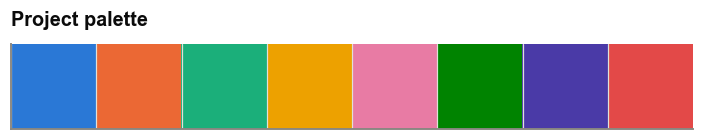

In [2]:
# A fixed, colorblind-safe categorical order (assigned in order, never cycled arbitrarily).
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "surface": "#ffffff"}

# Single-hue sequential ramp (light → dark blue) for magnitude encodings / heatmaps.
BLUES = LinearSegmentedColormap.from_list(
    "brand_blues", ["#eaf2fd", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])


def set_viz_theme() -> None:
    """Apply one consistent Matplotlib/Seaborn theme for the whole notebook."""
    sns.set_theme(style="whitegrid")
    mpl.rcParams.update({
        "figure.figsize": (9, 5), "figure.dpi": 110,
        "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
        "axes.edgecolor": INK["muted"], "axes.labelcolor": INK["secondary"],
        "axes.titlecolor": INK["primary"], "axes.titlesize": 13,
        "axes.titleweight": "bold", "axes.titlepad": 12, "axes.labelsize": 11,
        "axes.grid": True, "grid.color": INK["grid"], "grid.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "xtick.color": INK["muted"], "ytick.color": INK["muted"],
        "text.color": INK["primary"], "font.size": 11, "legend.frameon": False,
    })
    mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=PALETTE)


set_viz_theme()
sns.palplot(sns.color_palette(PALETTE))
plt.title("Project palette", loc="left", color=INK["primary"], fontweight="bold")
plt.show()

### Central configuration

Every tunable parameter lives in a single, documented `Config` object — there are **no unexplained magic numbers** scattered through the notebook. Changing an experiment (e.g. a stricter relevance threshold or a larger neighborhood) is a one-line edit here.

In [3]:
@dataclass(frozen=True)
class Config:
    """Central, documented configuration for the whole pipeline."""
    data_url: str = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    data_dir: Path = Path("data")

    # Preprocessing
    min_movie_ratings: int = 10      # keep movies with >= N ratings for CF → less cold-start noise & sparsity
    test_fraction: float = 0.20      # per-user hold-out share for evaluation

    # Evaluation
    relevance_threshold: float = 4.0 # rating >= this = a "liked"/relevant item for ranking metrics
    top_n: int = 10                  # length of the recommendation list shown to users

    # Models
    top_k_neighbors: int = 40        # neighborhood size for item/user-based CF
    svd_factors: int = 50            # latent dimensions for matrix factorization
    bias_reg_item: float = 10.0      # L2-style shrinkage for item bias (Koren regularization)
    bias_reg_user: float = 15.0      # shrinkage for user bias
    rating_clip: tuple = (0.5, 5.0)  # valid MovieLens rating range → clip predictions


CFG = Config()
CFG

Config(data_url='https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', data_dir=WindowsPath('data'), min_movie_ratings=10, test_fraction=0.2, relevance_threshold=4.0, top_n=10, top_k_neighbors=40, svd_factors=50, bias_reg_item=10.0, bias_reg_user=15.0, rating_clip=(0.5, 5.0))

<a id="loading"></a>
## 2. Data Loading & Overview
[↑ Back to top](#toc)

The dataset is fetched and unzipped **programmatically** on first run and cached locally thereafter, so the notebook is fully self-contained and reproducible — a reviewer can *Run All* with zero manual setup.

In [4]:
def download_movielens(url: str, data_dir: Path) -> Path:
    """Download & unzip MovieLens once; reuse the local copy on subsequent runs.

    Parameters
    ----------
    url : str
        Direct link to the MovieLens zip archive.
    data_dir : Path
        Destination directory for the extracted files.

    Returns
    -------
    Path
        Path to the extracted ``ml-latest-small`` folder.
    """
    target = data_dir / "ml-latest-small"
    if target.exists():
        return target
    data_dir.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(url, timeout=60) as response:
        archive = io.BytesIO(response.read())
    with zipfile.ZipFile(archive) as zf:
        zf.extractall(data_dir)
    return target


def load_movielens(cfg: Config) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load the ratings, movies and tags tables into tidy DataFrames."""
    folder = download_movielens(cfg.data_url, cfg.data_dir)
    ratings = pd.read_csv(folder / "ratings.csv")
    movies = pd.read_csv(folder / "movies.csv")
    tags = pd.read_csv(folder / "tags.csv")
    return ratings, movies, tags


ratings, movies, tags = load_movielens(CFG)
print(f"ratings : {ratings.shape[0]:>7,} rows × {ratings.shape[1]} cols")
print(f"movies  : {movies.shape[0]:>7,} rows × {movies.shape[1]} cols")
print(f"tags    : {tags.shape[0]:>7,} rows × {tags.shape[1]} cols")
ratings.head()

ratings : 100,836 rows × 4 cols
movies  :   9,742 rows × 3 cols
tags    :   3,683 rows × 4 cols


,userId,movieId,rating,timestamp
0,1,1,4.0000,964982703
1,1,3,4.0000,964981247
2,1,6,4.0000,964982224
3,1,47,5.0000,964983815
4,1,50,5.0000,964982931


A quick look at the two reference tables that describe the catalog:

In [5]:
display(movies.head())
tags.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


**Structure and dtypes** of the primary interactions table:

In [6]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


**Data-quality summary** — a compact audit of every table before we trust it:

In [7]:
def overview_table(frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Compact data-quality report: size, missing cells, duplicates, and memory."""
    rows = []
    for name, df in frames.items():
        rows.append({
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "missing_cells": int(df.isna().sum().sum()),
            "duplicate_rows": int(df.duplicated().sum()),
            "memory_MB": round(df.memory_usage(deep=True).sum() / 1e6, 2),
        })
    return pd.DataFrame(rows).set_index("table")


overview_table({"ratings": ratings, "movies": movies, "tags": tags})

,rows,columns,missing_cells,duplicate_rows,memory_MB
table,,,,,
ratings,100836,4,0,0,3.2300
movies,9742,3,0,0,1.4600
tags,3683,4,0,0,0.3100


**Headline metrics** that frame the entire modeling problem:

In [8]:
N_USERS = ratings["userId"].nunique()
N_ITEMS = ratings["movieId"].nunique()
DENSITY = len(ratings) / (N_USERS * N_ITEMS)
year_span = pd.to_datetime(ratings["timestamp"], unit="s").dt.year

print(f"Unique users     : {N_USERS:,}")
print(f"Unique movies    : {N_ITEMS:,}")
print(f"Total ratings    : {len(ratings):,}")
print(f"Rating scale     : {ratings['rating'].min()} – {ratings['rating'].max()} stars (0.5 steps)")
print(f"Matrix density   : {DENSITY:.2%}   (i.e. {1 - DENSITY:.2%} sparse)")
print(f"Interaction span : {year_span.min()} – {year_span.max()}")

Unique users     : 610
Unique movies    : 9,724
Total ratings    : 100,836
Rating scale     : 0.5 – 5.0 stars (0.5 steps)
Matrix density   : 1.70%   (i.e. 98.30% sparse)
Interaction span : 1996 – 2018


> **Reading the numbers.** The data is clean — **no missing cells and no duplicate ratings**. The single most important structural fact is that the user–item matrix is **~98% empty**: the average user has rated only a tiny fraction of the catalog. This *sparsity* is the central challenge every recommender below must overcome, and it is exactly why naive similarity on the raw matrix struggles.

<a id="eda"></a>
## 3. Exploratory Data Analysis
[↑ Back to top](#toc)

Before modeling, we build intuition for **how users rate**, **which titles dominate**, and **how sparse** the interaction signal really is. Each finding below has a direct modeling consequence, called out as we go.

<a id="eda-ratings"></a>
### 3.1 Distribution of Ratings

Understanding the rating scale's shape tells us whether users are generous or critical, and informs the **relevance threshold** we later use to define a "liked" item.

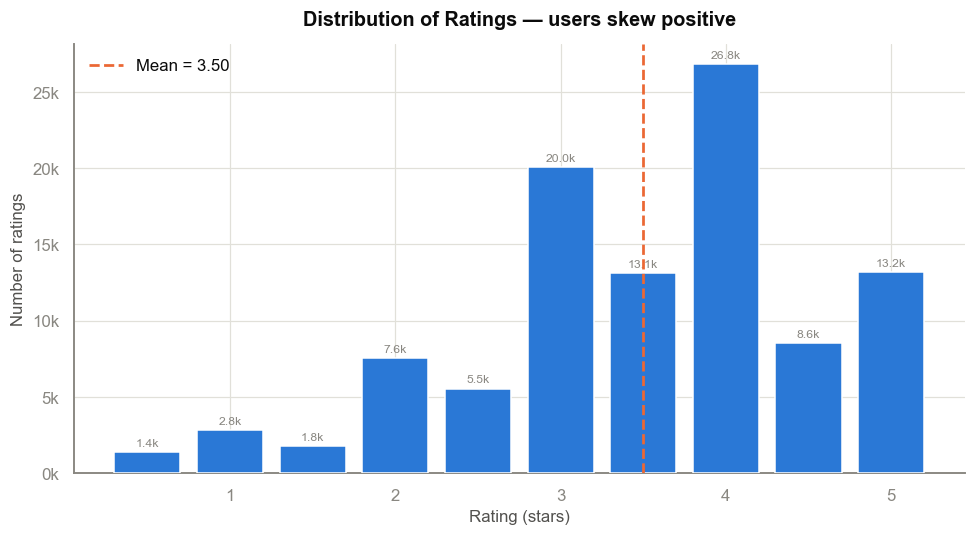

In [9]:
rating_counts = ratings["rating"].value_counts().sort_index()
mean_rating = ratings["rating"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(rating_counts.index, rating_counts.values, width=0.4, color=PALETTE[0], zorder=3)
ax.axvline(mean_rating, color=PALETTE[1], linestyle="--", linewidth=1.8,
           zorder=4, label=f"Mean = {mean_rating:.2f}")
ax.set_title("Distribution of Ratings — users skew positive")
ax.set_xlabel("Rating (stars)")
ax.set_ylabel("Number of ratings")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax.legend(loc="upper left")
for x, y in zip(rating_counts.index, rating_counts.values):
    ax.text(x, y + 250, f"{y/1000:.1f}k", ha="center", va="bottom",
            fontsize=8, color=INK["muted"])
plt.tight_layout()
plt.show()

**Takeaways**

- Ratings are **left-skewed toward positive** (mean ≈ 3.5). Whole-star ratings (3.0, 4.0, 5.0) dominate — users gravitate to round numbers.
- **4.0 is the single most common rating**, which makes it a natural, defensible cut-off for "the user liked this." We use **rating ≥ 4.0** as the *relevance* threshold in all ranking metrics.
- Positive skew also means a model that always predicts a high rating will look deceptively good on error metrics — a reason we complement RMSE/MAE with ranking metrics.

<a id="eda-activity"></a>
### 3.2 User & Item Activity — the long tail

Recommender data is almost always **long-tailed**: a few power users and blockbuster titles dominate, while most users and items have very little signal.

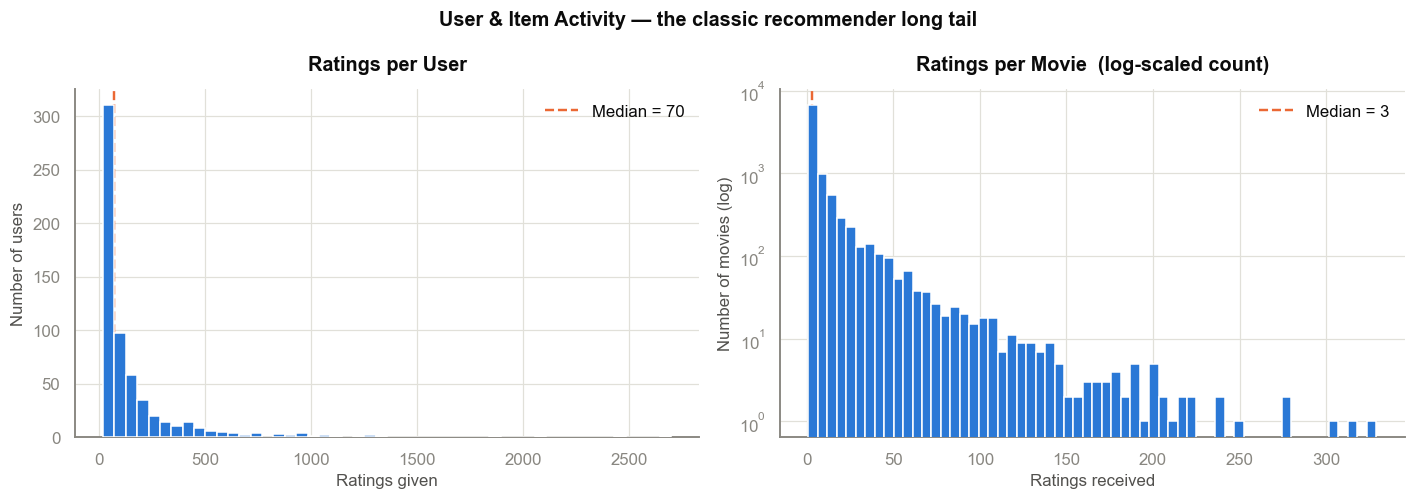

Median ratings / user : 70   (min 20, max 2698)
Median ratings / movie: 3   (min 1, max 329)
Movies with < 10 ratings: 77% of the catalog


In [10]:
ratings_per_user = ratings.groupby("userId").size()
ratings_per_movie = ratings.groupby("movieId").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].hist(ratings_per_user, bins=50, color=PALETTE[0], zorder=3)
axes[0].axvline(ratings_per_user.median(), color=PALETTE[1], ls="--", lw=1.6,
                label=f"Median = {ratings_per_user.median():.0f}")
axes[0].set_title("Ratings per User")
axes[0].set_xlabel("Ratings given"); axes[0].set_ylabel("Number of users")
axes[0].legend()

axes[1].hist(ratings_per_movie, bins=60, color=PALETTE[0], zorder=3)
axes[1].set_yscale("log")
axes[1].axvline(ratings_per_movie.median(), color=PALETTE[1], ls="--", lw=1.6,
                label=f"Median = {ratings_per_movie.median():.0f}")
axes[1].set_title("Ratings per Movie  (log-scaled count)")
axes[1].set_xlabel("Ratings received"); axes[1].set_ylabel("Number of movies (log)")
axes[1].legend()

fig.suptitle("User & Item Activity — the classic recommender long tail",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Median ratings / user : {ratings_per_user.median():.0f}"
      f"   (min {ratings_per_user.min()}, max {ratings_per_user.max()})")
print(f"Median ratings / movie: {ratings_per_movie.median():.0f}"
      f"   (min {ratings_per_movie.min()}, max {ratings_per_movie.max()})")
print(f"Movies with < {CFG.min_movie_ratings} ratings: "
      f"{(ratings_per_movie < CFG.min_movie_ratings).mean():.0%} of the catalog")

**Takeaways**

- Every user has rated at least 20 movies (a property of this curated dataset), so **user cold-start is mild** here — good news for collaborative filtering.
- The movie side is brutally long-tailed: a large share of titles have only a handful of ratings. Similarity estimates for these thin items are pure noise.
- **Modeling consequence:** for the collaborative-filtering models we restrict to movies with **≥ `min_movie_ratings` (10)** ratings. This is a standard denoising step — it trims the unreliable tail while retaining the vast majority of *interactions*.

<a id="eda-popular"></a>
### 3.3 Most Popular & Top-Rated Titles — and why a plain average lies

The obvious "best movies" list — sort by average rating — is a trap: a film with a single 5★ rating would top *Titanic*. We fix this with an **IMDb-style Bayesian weighted rating** that shrinks low-volume titles toward the global mean.

Global mean rating C = 3.502   |   min-votes threshold m = 27


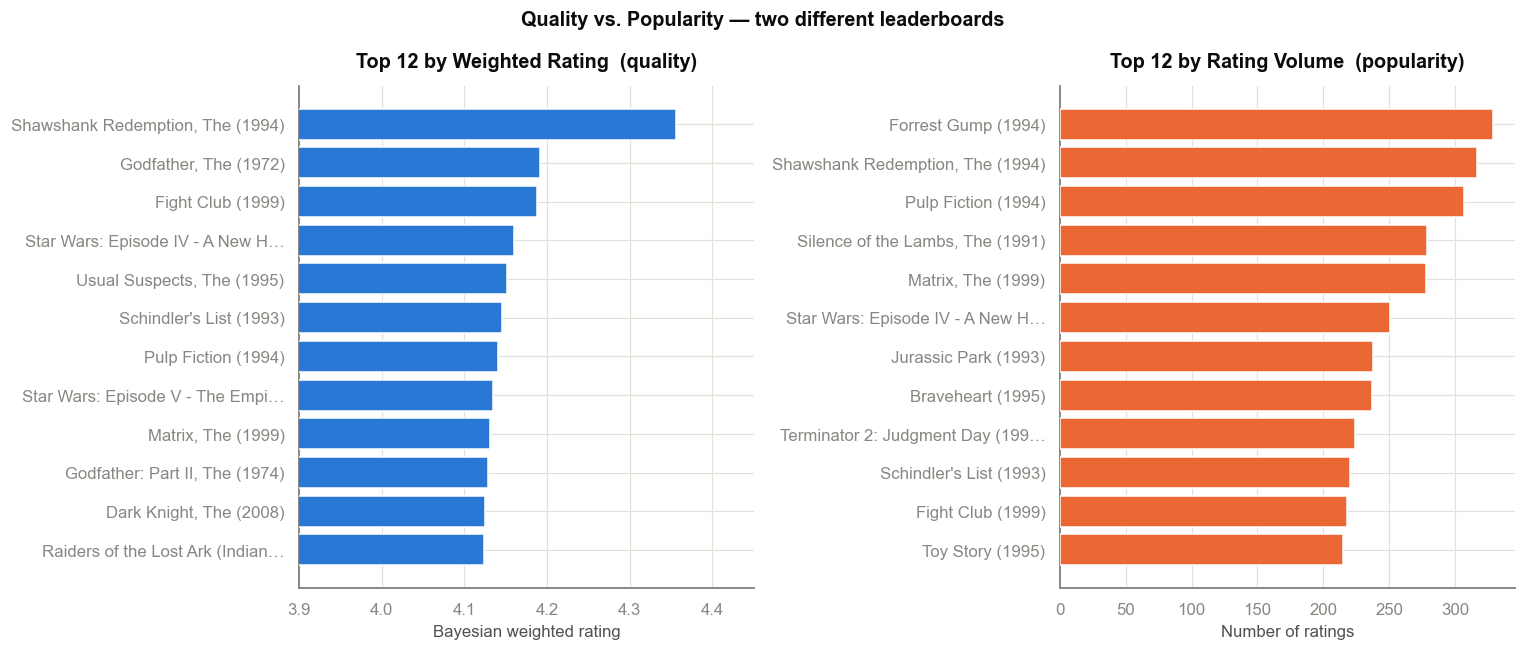

In [11]:
def add_weighted_rating(ratings: pd.DataFrame, movies: pd.DataFrame,
                        quantile: float = 0.90) -> tuple[pd.DataFrame, float, float]:
    r"""Attach an IMDb-style Bayesian weighted rating to each movie.

    .. math::
        WR = \frac{v}{v+m}\,R + \frac{m}{v+m}\,C

    where ``v`` = vote count, ``R`` = movie mean, ``C`` = global mean, and
    ``m`` = a minimum-votes threshold (a high quantile of the vote counts).
    Shrinking toward ``C`` prevents a movie with a handful of votes from
    outranking a broadly-loved classic.

    Returns the per-movie stats, the global mean ``C`` and the threshold ``m``.
    """
    stats = ratings.groupby("movieId")["rating"].agg(count="count", mean="mean")
    C = ratings["rating"].mean()
    m = stats["count"].quantile(quantile)
    stats["weighted_rating"] = ((stats["count"] / (stats["count"] + m)) * stats["mean"]
                                + (m / (stats["count"] + m)) * C)
    stats = stats.join(movies.set_index("movieId")[["title", "genres"]])
    return stats, C, m


movie_stats, C_GLOBAL, M_VOTES = add_weighted_rating(ratings, movies)
print(f"Global mean rating C = {C_GLOBAL:.3f}   |   min-votes threshold m = {M_VOTES:.0f}")

shorten = lambda s, n=32: s if len(s) <= n else s[:n - 1] + "…"
top_wr = movie_stats.sort_values("weighted_rating", ascending=False).head(12)
top_pop = movie_stats.sort_values("count", ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh([shorten(t) for t in top_wr["title"]][::-1],
             top_wr["weighted_rating"][::-1], color=PALETTE[0], zorder=3)
axes[0].set_xlim(3.9, 4.45)
axes[0].set_title("Top 12 by Weighted Rating  (quality)")
axes[0].set_xlabel("Bayesian weighted rating")

axes[1].barh([shorten(t) for t in top_pop["title"]][::-1],
             top_pop["count"][::-1], color=PALETTE[1], zorder=3)
axes[1].set_title("Top 12 by Rating Volume  (popularity)")
axes[1].set_xlabel("Number of ratings")

fig.suptitle("Quality vs. Popularity — two different leaderboards",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Takeaways**

- The two leaderboards overlap but are **not identical**: critically adored films (*The Shawshank Redemption*, *The Godfather*) top the quality list, while the volume list is dominated by broadly-watched hits (*Forrest Gump*, *Pulp Fiction*).
- The weighted rating is the scoring function for our **Popularity baseline** — a genuinely strong, non-personalized benchmark that every personalized model must beat to justify its complexity.

<a id="eda-genres"></a>
### 3.4 Genres & Release Years

Genre and release-year structure tells us what content-based features have to work with, and reveals catalog composition.

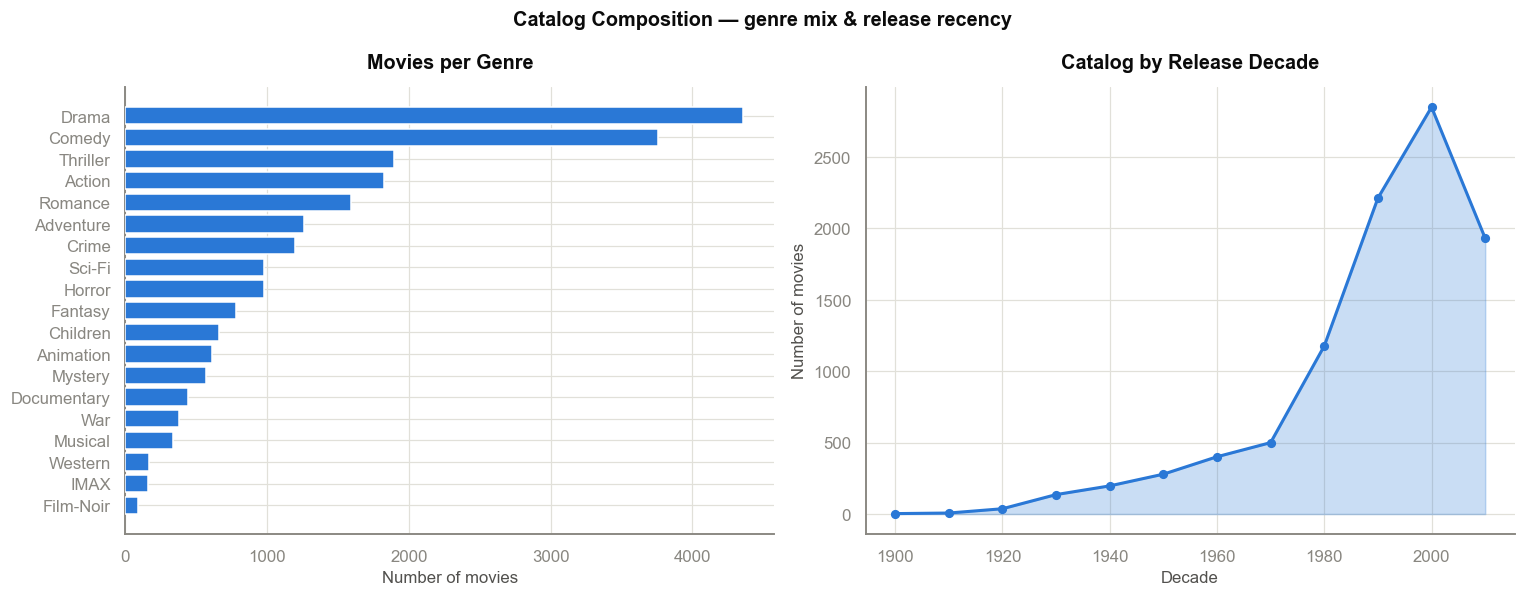

In [12]:
# Genres are pipe-separated; explode to one row per (movie, genre).
genre_exploded = movies.assign(genre=movies["genres"].str.split("|")).explode("genre")
genre_counts = (genre_exploded["genre"].value_counts()
                .drop(labels=["(no genres listed)"], errors="ignore"))

movies_year = movies.assign(year=movies["title"].str.extract(r"\((\d{4})\)").astype(float))
decade = (movies_year["year"] // 10 * 10).dropna()
decade_counts = decade.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].barh(genre_counts.index[::-1], genre_counts.values[::-1], color=PALETTE[0], zorder=3)
axes[0].set_title("Movies per Genre")
axes[0].set_xlabel("Number of movies")

axes[1].fill_between(decade_counts.index, decade_counts.values,
                     color=PALETTE[0], alpha=0.25, zorder=2)
axes[1].plot(decade_counts.index, decade_counts.values, color=PALETTE[0],
             marker="o", markersize=5, linewidth=2, zorder=3)
axes[1].set_title("Catalog by Release Decade")
axes[1].set_xlabel("Decade"); axes[1].set_ylabel("Number of movies")

fig.suptitle("Catalog Composition — genre mix & release recency",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Takeaways**

- **Drama** and **Comedy** dominate the catalog, followed by Thriller and Action — a genre signal rich enough to power content-based similarity.
- The catalog skews toward **1990s–2000s** releases, typical of MovieLens. Release year is a useful secondary content feature and a lever for freshness in production.

<a id="eda-sparsity"></a>
### 3.5 Sparsity of the Interaction Matrix

Sparsity is *the* defining property of recommendation data. We already know the full matrix is ~98% empty; the heatmap below makes it visceral by zooming into the **densest possible corner** — the 40 most active users against the 40 most-rated movies.

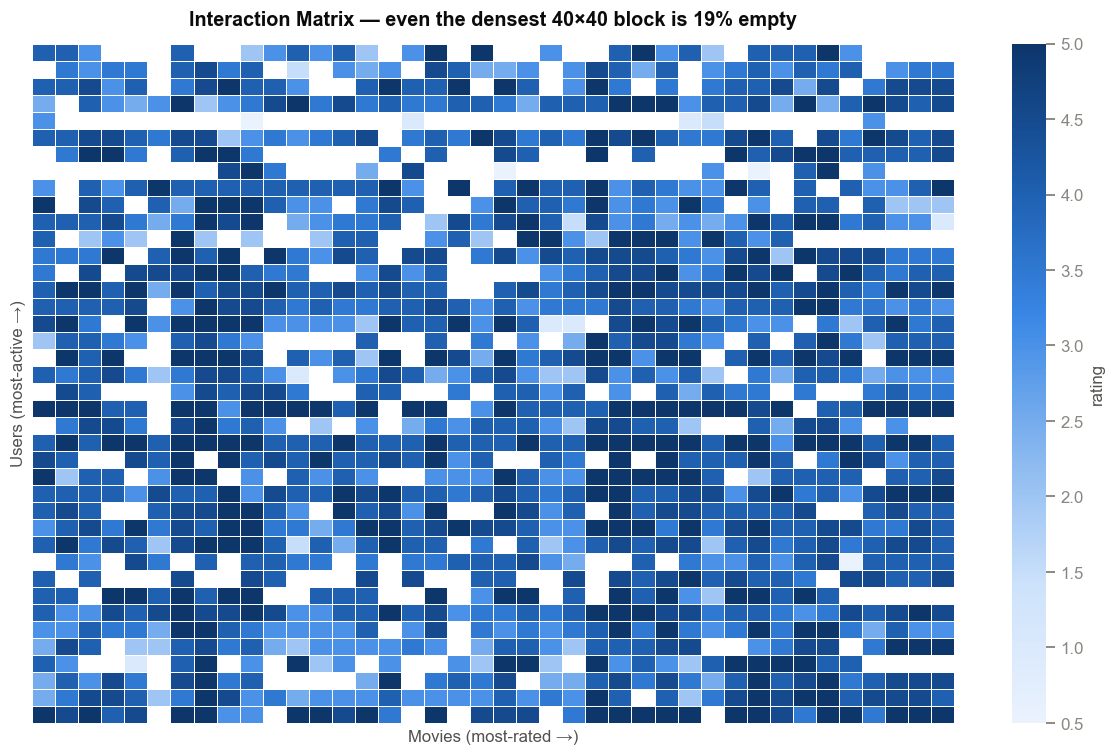

Fill rate of the densest 40×40 block : 80.7%
Fill rate of the full matrix         : 1.70%


In [13]:
top_users = ratings_per_user.sort_values(ascending=False).head(40).index
top_movies = ratings_per_movie.sort_values(ascending=False).head(40).index
dense_block = (ratings[ratings["userId"].isin(top_users) & ratings["movieId"].isin(top_movies)]
               .pivot_table(index="userId", columns="movieId", values="rating"))
block_fill = dense_block.notna().mean().mean()

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(dense_block, cmap=BLUES, cbar_kws={"label": "rating"},
            linewidths=0.4, linecolor=INK["surface"], ax=ax)
ax.set_title(f"Interaction Matrix — even the densest 40×40 block is "
             f"{1 - block_fill:.0%} empty")
ax.set_xlabel("Movies (most-rated →)")
ax.set_ylabel("Users (most-active →)")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f"Fill rate of the densest 40×40 block : {block_fill:.1%}")
print(f"Fill rate of the full matrix         : {DENSITY:.2%}")

**Takeaways**

- Even among the *most active* users and *most popular* movies, most cells are blank. In the full matrix, blanks are the overwhelming majority.
- This is why **memory-based similarity on the raw matrix is fragile** and why **matrix factorization** — which learns low-dimensional latent factors that generalize across the gaps — is so effective on this kind of data.

---

### 🧭 EDA summary

| Observation | Modeling consequence |
|---|---|
| Ratings skew positive; 4★ is the mode | Use **rating ≥ 4** as the relevance threshold |
| Movie activity is long-tailed | Filter to movies with **≥ 10 ratings** for CF |
| Matrix is ~98% sparse | Prefer **latent-factor** methods; denoise neighborhoods |
| Rich genre & tag text exists | Enables **content-based** filtering & cold-start handling |

<a id="preprocessing"></a>
## 4. Data Preprocessing & Feature Engineering
[↑ Back to top](#toc)

Three preparation steps flow directly from the EDA. Each is justified below before any code runs.

1. **Content features.** Combine each movie's genres with its user-applied tags into a single text "soup", then vectorize with **TF-IDF**. This gives every movie a content fingerprint for content-based similarity and cold-start recommendations.
2. **Denoising filter.** Restrict the collaborative-filtering universe to movies with **≥ `min_movie_ratings`** ratings, removing the noisy long tail identified in §3.2.
3. **Leakage-safe split.** Hold out a fraction of **each user's** ratings for testing, so every user appears in both train and test — a requirement for computing per-user ranking metrics without leakage.

#### 4.1 Content features — genres + tags → TF-IDF

In [14]:
def build_content_features(movies: pd.DataFrame,
                           tags: pd.DataFrame) -> tuple[pd.DataFrame, "sparse", TfidfVectorizer]:
    """Build a per-movie 'content soup' (genres + user tags) and TF-IDF vectorize it.

    Genres provide a clean, universal signal; user tags add fine-grained,
    crowd-sourced descriptors (e.g. "dark comedy", "time travel"). Together they
    form a richer content fingerprint than genres alone.
    """
    tag_soup = (tags.assign(tag=tags["tag"].astype(str))
                .groupby("movieId")["tag"].apply(" ".join))
    feat = movies.set_index("movieId").copy()
    feat["genres_clean"] = (feat["genres"]
                            .str.replace("(no genres listed)", "", regex=False)
                            .str.replace("|", " ", regex=False))
    feat["tag_str"] = pd.Series(feat.index.map(tag_soup), index=feat.index).fillna("")
    feat["soup"] = (feat["genres_clean"] + " " + feat["tag_str"]).str.strip()

    # min_df=2 drops one-off tags (typos, personal notes) that add only noise.
    vectorizer = TfidfVectorizer(stop_words="english", min_df=2)
    matrix = vectorizer.fit_transform(feat["soup"])
    return feat, matrix, vectorizer


movies_feat, CONTENT_TFIDF, tfidf_vectorizer = build_content_features(movies, tags)
CONTENT_MOVIE_IDS = movies_feat.index.to_numpy()
MID_TO_ROW = {mid: i for i, mid in enumerate(CONTENT_MOVIE_IDS)}

print(f"TF-IDF content matrix: {CONTENT_TFIDF.shape[0]:,} movies "
      f"× {CONTENT_TFIDF.shape[1]:,} features")
print("Example soup:", movies_feat.loc[1, "soup"][:90], "…")

TF-IDF content matrix: 9,742 movies × 725 features
Example soup: Adventure Animation Children Comedy Fantasy pixar pixar fun …


#### 4.2 Denoising filter + index maps for the collaborative-filtering universe

In [15]:
# Keep only movies with enough ratings to yield reliable similarity estimates.
movie_rating_counts = ratings.groupby("movieId")["userId"].transform("size")
cf_ratings = ratings[movie_rating_counts >= CFG.min_movie_ratings].copy()

# Contiguous integer indices for fast dense-matrix math.
USER_IDS = np.sort(cf_ratings["userId"].unique())
ITEM_IDS = np.sort(cf_ratings["movieId"].unique())
U_INDEX = {u: i for i, u in enumerate(USER_IDS)}
I_INDEX = {m: j for j, m in enumerate(ITEM_IDS)}
N_U, N_I = len(USER_IDS), len(ITEM_IDS)

retained = len(cf_ratings) / len(ratings)
print(f"CF universe: {N_U:,} users × {N_I:,} movies")
print(f"Kept {len(cf_ratings):,} of {len(ratings):,} ratings "
      f"({retained:.1%}) after the ≥{CFG.min_movie_ratings}-ratings filter")
print(f"Dropped {N_ITEMS - N_I:,} thin-tail movies "
      f"({1 - N_I / N_ITEMS:.0%} of titles, but only {1 - retained:.1%} of interactions)")

CF universe: 610 users × 2,269 movies
Kept 81,116 of 100,836 ratings (80.4%) after the ≥10-ratings filter
Dropped 7,455 thin-tail movies (77% of titles, but only 19.6% of interactions)


#### 4.3 Leakage-safe, per-user train/test split

In [16]:
def train_test_split_per_user(df: pd.DataFrame, test_fraction: float,
                              seed: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Hold out a fraction of EACH user's ratings for testing.

    A per-user split (rather than a global random split) guarantees every user
    has both training history and held-out items, which is required to compute
    per-user ranking metrics (Precision@K, Recall@K, NDCG@K) without leakage.
    """
    rng = np.random.default_rng(seed)
    test_positions: list[int] = []
    for _, index in df.groupby("userId").groups.items():
        index = np.asarray(index)
        k = max(1, int(round(len(index) * test_fraction)))
        test_positions.extend(rng.choice(index, size=k, replace=False))
    is_test = df.index.isin(test_positions)
    return df[~is_test].copy(), df[is_test].copy()


train_df, test_df = train_test_split_per_user(cf_ratings, CFG.test_fraction, RANDOM_STATE)


def to_dense_matrix(df: pd.DataFrame) -> np.ndarray:
    """Pivot a ratings frame into a dense (users × items) float32 matrix; unknowns = 0."""
    mat = np.zeros((N_U, N_I), dtype=np.float32)
    rows = df["userId"].map(U_INDEX).to_numpy()
    cols = df["movieId"].map(I_INDEX).to_numpy()
    mat[rows, cols] = df["rating"].to_numpy()
    return mat


R_train = to_dense_matrix(train_df)
MASK_TRAIN = R_train > 0                         # True where a training rating exists

# Per-user mean and mean-centered matrix (basis for neighborhood similarity).
GLOBAL_MEAN = float(R_train[MASK_TRAIN].mean())
USER_CNT = MASK_TRAIN.sum(axis=1)
USER_MEAN = np.divide(R_train.sum(axis=1), USER_CNT,
                      out=np.full(N_U, GLOBAL_MEAN, dtype=np.float32), where=USER_CNT > 0)
R_CENTERED = np.where(MASK_TRAIN, R_train - USER_MEAN[:, None], 0.0).astype(np.float32)

print(f"Train ratings : {len(train_df):,}   ({MASK_TRAIN.mean():.2%} dense)")
print(f"Test ratings  : {len(test_df):,}")
print(f"Train matrix  : {R_train.shape}  •  global mean {GLOBAL_MEAN:.3f}")

Train ratings : 64,889   (4.69% dense)
Test ratings  : 16,227
Train matrix  : (610, 2269)  •  global mean 3.571


<a id="models"></a>
## 5. Recommendation Models
[↑ Back to top](#toc)

We build **five** families of increasing sophistication. Each targets a different weakness of the last:

| # | Model | Idea | Solves |
|---|-------|------|--------|
| 5.1 | **Popularity** | Recommend the globally best titles | A strong, non-personalized baseline |
| 5.2 | **Content-based** | Match items by their genre/tag fingerprint | Cold-start & explainability |
| 5.3 | **Neighborhood CF** | "Users like you liked…" / "similar items" | Personalization from behavior |
| 5.4 | **Matrix factorization (SVD)** | Learn latent taste factors | Sparsity & rating accuracy |
| 5.5 | **Hybrid** | Blend the complementary strengths | Robust top-*N* ranking |

Throughout, we separate two prediction targets that recommenders are often (wrongly) evaluated as one:

- **Rating prediction** — *how many stars* would this user give? → scored with RMSE/MAE.
- **Top-*N* ranking** — *which items* should we put on the screen? → scored with Precision@K, Recall@K, NDCG@K.

<a id="model-popularity"></a>
### 5.1 Popularity Baseline

The simplest possible recommender: show everyone the same globally-best titles, scored by the **Bayesian weighted rating** from §3.3. It ignores personalization entirely — which is precisely why it is the benchmark. *If a personalized model can't beat "show everyone the classics," it isn't earning its complexity.*

In [17]:
# Align the weighted-rating score to the CF item universe; unseen → global mean.
POP_SCORE = movie_stats["weighted_rating"].reindex(ITEM_IDS).fillna(C_GLOBAL).to_numpy()
POP_PRED = np.tile(POP_SCORE, (N_U, 1))          # identical row for every user

print("Popularity model ready — top 5 titles it recommends to everyone:")
top5 = np.argsort(-POP_SCORE)[:5]
for rank, j in enumerate(top5, 1):
    print(f"  {rank}. {movies_feat.loc[ITEM_IDS[j], 'title']}")

Popularity model ready — top 5 titles it recommends to everyone:
  1. Shawshank Redemption, The (1994)
  2. Godfather, The (1972)
  3. Fight Club (1999)
  4. Star Wars: Episode IV - A New Hope (1977)
  5. Usual Suspects, The (1995)


<a id="model-content"></a>
### 5.2 Content-Based Filtering

Content-based filtering recommends items *similar in content* to what a user already likes — no other users required. We represent each movie by its TF-IDF content vector (§4.1) and build a **user taste profile** as the rating-weighted average of the content vectors of the movies they liked. Recommendations are the catalog items whose content is most **cosine-similar** to that profile.

**Why it matters for the business:** content-based is the answer to **cold-start** — a brand-new title with zero ratings can still be recommended the moment its metadata exists, and recommendations are **explainable** ("because you liked other sci-fi thrillers").

In [18]:
# Restrict the content matrix to the CF item universe, aligned to ITEM_IDS order.
CONTENT_ROWS = np.array([MID_TO_ROW[m] for m in ITEM_IDS])
CONTENT_SUB = CONTENT_TFIDF[CONTENT_ROWS].toarray()      # items × features (dense, small)


def build_user_profiles(centered: np.ndarray, content: np.ndarray) -> np.ndarray:
    """Taste profile = above-average-rating-weighted sum of liked items' content vectors."""
    weights = np.clip(centered, 0, None)          # emphasise items rated above the user's mean
    return weights @ content


USER_PROFILES = build_user_profiles(R_CENTERED, CONTENT_SUB)
CONTENT_PRED = cosine_similarity(USER_PROFILES, CONTENT_SUB)   # users × items relevance
print(f"User taste profiles: {USER_PROFILES.shape}  →  content scores {CONTENT_PRED.shape}")


def similar_movies(title_query: str, n: int = 10) -> tuple[pd.DataFrame, str]:
    """Item-to-item content recommendations: the n most content-similar movies."""
    matches = movies_feat[movies_feat["title"].str.contains(title_query, case=False,
                                                            na=False, regex=False)]
    if matches.empty:
        raise ValueError(f"No movie title matches {title_query!r}")
    seed_id = matches.index[0]
    sims = cosine_similarity(CONTENT_TFIDF[MID_TO_ROW[seed_id]], CONTENT_TFIDF).ravel()
    order = np.argsort(-sims)[1:n + 1]            # skip the movie itself at rank 0
    out = movies_feat.iloc[order][["title", "genres"]].copy()
    out["similarity"] = sims[order]
    return out.reset_index(drop=True), matches["title"].iloc[0]

User taste profiles: (610, 725)  →  content scores (610, 2269)


**Sanity check** — item-to-item content similarity for a well-known title:

In [19]:
neighbors, seed_title = similar_movies("Toy Story (1995)", n=8)
print(f"Movies most similar in content to: {seed_title}\n")
neighbors

Movies most similar in content to: Toy Story (1995)



,title,genres,similarity
0,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.8622
1,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.6440
2,Up (2009),Adventure|Animation|Children|Drama,0.3879
3,Guardians of the Galaxy 2 (2017),Action|Adventure|Sci-Fi,0.3677
4,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,0.3579
5,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,0.3579
6,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,0.3579
7,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,0.3579


<a id="model-cf"></a>
### 5.3 Collaborative Filtering — Neighborhood (Item & User)

Collaborative filtering (CF) makes no use of content; it learns purely from the **pattern of interactions**. We implement both classic neighborhood variants on the mean-centered matrix, using **cosine similarity** truncated to each row's **top-K neighbors** (a standard denoising and efficiency step):

- **Item-based CF** — "*because you rated these movies highly, here are similar movies*." Similarity is computed between item rating-vectors.
- **User-based CF** — "*users with taste like yours also enjoyed…*." Similarity is computed between user rating-vectors.

For **rating prediction** we use the standard similarity-weighted, mean-adjusted formula. For **ranking** we score by the *aggregate neighbor evidence* (the un-normalized weighted sum) — this avoids over-promoting an obscure item supported by a single strong neighbor, a subtle but important distinction between the two tasks.

In [20]:
def top_k_similarity(sim: np.ndarray, k: int) -> np.ndarray:
    """Keep each row's k strongest neighbors (zero the rest); drop self-similarity."""
    sim = sim.copy()
    np.fill_diagonal(sim, 0.0)
    if sim.shape[1] > k:
        weakest = np.argpartition(-sim, k, axis=1)[:, k:]     # indices beyond the top-k
        np.put_along_axis(sim, weakest, 0.0, axis=1)
    return sim


def neighborhood_scores(centered: np.ndarray, mask: np.ndarray, similarity: np.ndarray,
                        user_mean: np.ndarray, axis: str) -> tuple[np.ndarray, np.ndarray]:
    """Return (rating_prediction, ranking_evidence) for item- or user-based CF.

    ``axis='item'`` → item-based (items × items similarity);
    ``axis='user'`` → user-based (users × users similarity).
    """
    if axis == "item":
        evidence = centered @ similarity.T                    # users × items
        denom = mask.astype(np.float32) @ np.abs(similarity).T
    else:                                                     # user-based
        evidence = similarity @ centered
        denom = np.abs(similarity) @ mask.astype(np.float32)
    prediction = user_mean[:, None] + np.divide(evidence, denom,
                                                out=np.zeros_like(evidence), where=denom > 0)
    return prediction, evidence


# Item-based CF
ITEM_SIM = top_k_similarity(cosine_similarity(R_CENTERED.T), CFG.top_k_neighbors).astype(np.float32)
ITEMCF_PRED, ITEM_EVIDENCE = neighborhood_scores(R_CENTERED, MASK_TRAIN, ITEM_SIM, USER_MEAN, "item")
ITEMCF_PRED = np.clip(ITEMCF_PRED, *CFG.rating_clip)

# User-based CF
USER_SIM = top_k_similarity(cosine_similarity(R_CENTERED), CFG.top_k_neighbors).astype(np.float32)
USERCF_PRED, USER_EVIDENCE = neighborhood_scores(R_CENTERED, MASK_TRAIN, USER_SIM, USER_MEAN, "user")
USERCF_PRED = np.clip(USERCF_PRED, *CFG.rating_clip)

print(f"Item–item similarity: {ITEM_SIM.shape}  |  User–user similarity: {USER_SIM.shape}")
print(f"Top-{CFG.top_k_neighbors} neighbors retained per row.")

Item–item similarity: (2269, 2269)  |  User–user similarity: (610, 610)
Top-40 neighbors retained per row.


<a id="model-svd"></a>
### 5.4 Matrix Factorization (SVD)

Matrix factorization is the workhorse of modern recommenders. It decomposes the sparse rating matrix into **low-dimensional latent factors** — compact vectors that encode taste ("gritty crime drama", "feel-good animation") without us ever naming them. Because the factors generalize across the empty cells, MF handles sparsity far better than memory-based similarity.

Two design choices lift this well above a textbook `svds` call:

1. **Regularized baseline first.** We remove global, per-user and per-item **biases** (some users rate generously, some movies are broadly loved) with *shrinkage* (Koren regularization) so low-support estimates don't run wild. SVD then models only the **interaction residual** — the personalized signal that remains.
2. **Clipping** predictions to the valid rating range.

In [21]:
def compute_biases(R: np.ndarray, mask: np.ndarray,
                   reg_item: float, reg_user: float) -> tuple[float, np.ndarray, np.ndarray]:
    """Regularized global / item / user biases (Koren).

    The shrinkage terms ``reg_item`` / ``reg_user`` pull estimates from
    low-support items/users toward zero, preventing a movie (or user) with a
    handful of ratings from acquiring an extreme bias.
    """
    mu = float(R[mask].mean())
    item_cnt = mask.sum(axis=0)
    b_i = np.where(mask, R - mu, 0.0).sum(axis=0) / (reg_item + item_cnt)
    user_cnt = mask.sum(axis=1)
    b_u = np.where(mask, R - mu - b_i[None, :], 0.0).sum(axis=1) / (reg_user + user_cnt)
    return mu, b_u, b_i


def factorize_residuals(R: np.ndarray, mask: np.ndarray, mu: float,
                        b_u: np.ndarray, b_i: np.ndarray, k: int) -> tuple[np.ndarray, np.ndarray]:
    """Truncated SVD on the baseline residual R − (μ + b_u + b_i)."""
    baseline = mu + b_u[:, None] + b_i[None, :]
    residual = np.where(mask, R - baseline, 0.0).astype(np.float64)
    U, sigma, Vt = svds(residual, k=k)
    personalization = U @ np.diag(sigma) @ Vt
    return baseline, personalization


MU_B, B_U, B_I = compute_biases(R_train, MASK_TRAIN, CFG.bias_reg_item, CFG.bias_reg_user)
BASELINE_PRED = np.clip(MU_B + B_U[:, None] + B_I[None, :], *CFG.rating_clip)

BASELINE_RAW, SVD_PERSONALIZATION = factorize_residuals(
    R_train, MASK_TRAIN, MU_B, B_U, B_I, CFG.svd_factors)
SVD_PRED = np.clip(BASELINE_RAW + SVD_PERSONALIZATION, *CFG.rating_clip)

print(f"Learned {CFG.svd_factors} latent factors on the bias-adjusted residual.")
print(f"Baseline (bias-only) and SVD prediction matrices: {SVD_PRED.shape}")

Learned 50 latent factors on the bias-adjusted residual.
Baseline (bias-only) and SVD prediction matrices: (610, 2269)


<a id="model-hybrid"></a>
### 5.5 Hybrid Model

No single model wins everywhere: neighborhood CF ranks well, SVD predicts ratings well, and content-based reaches cold-start items. A **hybrid** blends their per-user scores — each min-max normalized to `[0, 1]` so heterogeneous scales combine fairly — into one ranking. The weights favor the strongest ranker (user-based CF) while retaining the personalization of SVD and the coverage of content.

In [22]:
def minmax_rows(matrix: np.ndarray) -> np.ndarray:
    """Scale each user's score row to [0, 1] so different models can be blended fairly."""
    lo = matrix.min(axis=1, keepdims=True)
    hi = matrix.max(axis=1, keepdims=True)
    return (matrix - lo) / np.where(hi - lo > 0, hi - lo, 1.0)


HYBRID_WEIGHTS = {"user_cf": 0.50, "svd": 0.35, "content": 0.15}
HYBRID_PRED = (HYBRID_WEIGHTS["user_cf"] * minmax_rows(USER_EVIDENCE)
               + HYBRID_WEIGHTS["svd"] * minmax_rows(SVD_PRED)
               + HYBRID_WEIGHTS["content"] * minmax_rows(CONTENT_PRED))

print("Hybrid blend weights:", HYBRID_WEIGHTS)

Hybrid blend weights: {'user_cf': 0.5, 'svd': 0.35, 'content': 0.15}


<a id="evaluation"></a>
## 6. Model Evaluation
[↑ Back to top](#toc)

We evaluate on the held-out test set with metrics matched to each task:

**Rating prediction** (how accurate are the star predictions?)
- **RMSE** — root mean squared error; penalizes large misses heavily.
- **MAE** — mean absolute error; the average miss in stars.

**Top-*N* ranking** (is the *list* we show any good?) — computed at *K = `top_n`*, treating a held-out rating ≥ `relevance_threshold` as a hit:
- **Precision@K** — of the K we recommended, what fraction were relevant?
- **Recall@K** — of everything the user liked, what fraction did we surface in the top K?
- **NDCG@K** — like precision, but rewards putting relevant items **higher** in the list.
- **Catalog coverage** — the share of the catalog the model ever recommends; a proxy for **diversity** and long-tail exposure (a business-critical, non-accuracy dimension).

This split matters: *the model that minimizes RMSE is not necessarily the model that produces the best-ranked list* — a lesson the results below make concrete.

#### 6.1 Rating-prediction accuracy (RMSE / MAE)

In [23]:
TEST_U = test_df["userId"].map(U_INDEX).to_numpy()
TEST_I = test_df["movieId"].map(I_INDEX).to_numpy()
TEST_R = test_df["rating"].to_numpy()


def rating_errors(pred: np.ndarray) -> dict[str, float]:
    """RMSE and MAE of a full prediction matrix over the held-out test ratings."""
    p = pred[TEST_U, TEST_I]
    return {"RMSE": float(np.sqrt(mean_squared_error(TEST_R, p))),
            "MAE": float(mean_absolute_error(TEST_R, p))}


rating_models = {"Baseline (bias)": BASELINE_PRED, "Item-based CF": ITEMCF_PRED,
                 "User-based CF": USERCF_PRED, "SVD (MF)": SVD_PRED}
rating_report = pd.DataFrame({n: rating_errors(m) for n, m in rating_models.items()}).T
rating_report.sort_values("RMSE")

,RMSE,MAE
SVD (MF),0.8314,0.6416
Baseline (bias),0.8404,0.6497
User-based CF,0.8687,0.6614
Item-based CF,0.8847,0.6606


#### 6.2 Top-*N* ranking quality (Precision@K, Recall@K, NDCG@K, Coverage)

In [24]:
# Relevant (liked) held-out items per user.
RELEVANT_BY_USER = (test_df[test_df["rating"] >= CFG.relevance_threshold]
                    .assign(u=lambda d: d["userId"].map(U_INDEX),
                            i=lambda d: d["movieId"].map(I_INDEX))
                    .groupby("u")["i"].apply(set).to_dict())


def _ranked_topk(score_row: np.ndarray, seen: np.ndarray, k: int) -> np.ndarray:
    """Indices of the top-k unseen items for one user, best first."""
    row = score_row.astype(np.float64).copy()
    row[seen] = -np.inf                          # never recommend an already-seen item
    top = np.argpartition(-row, k)[:k]
    return top[np.argsort(-row[top])]


def ranking_at_k(score: np.ndarray, k: int) -> dict[str, float]:
    """Mean Precision@k, Recall@k and NDCG@k over users with >= 1 relevant test item."""
    idcg = np.cumsum(1.0 / np.log2(np.arange(2, k + 2)))     # ideal DCG for 1..k hits
    precisions, recalls, ndcgs = [], [], []
    for u, relevant in RELEVANT_BY_USER.items():
        top = _ranked_topk(score[u], MASK_TRAIN[u], k)
        hits = np.array([it in relevant for it in top], dtype=float)
        precisions.append(hits.sum() / k)
        recalls.append(hits.sum() / len(relevant))
        dcg = (hits / np.log2(np.arange(2, k + 2))).sum()
        ndcgs.append(dcg / idcg[min(len(relevant), k) - 1])
    return {f"Precision@{k}": np.mean(precisions),
            f"Recall@{k}": np.mean(recalls),
            f"NDCG@{k}": np.mean(ndcgs)}


def catalog_coverage(score: np.ndarray, k: int) -> float:
    """Fraction of the catalog that appears in at least one user's top-k list."""
    recommended: set[int] = set()
    for u in range(N_U):
        recommended.update(_ranked_topk(score[u], MASK_TRAIN[u], k).tolist())
    return len(recommended) / N_I


# For ranking, neighborhood models use aggregate-evidence scores (see §5.3).
ranking_models = {"Popularity": POP_PRED, "Content-based": CONTENT_PRED,
                  "Item-based CF": ITEM_EVIDENCE, "User-based CF": USER_EVIDENCE,
                  "SVD (MF)": SVD_PRED, "Hybrid": HYBRID_PRED}

ranking_report = pd.DataFrame({n: ranking_at_k(m, CFG.top_n)
                               for n, m in ranking_models.items()}).T
ranking_report["Coverage"] = [catalog_coverage(m, CFG.top_n) for m in ranking_models.values()]
n_eval_users = len(RELEVANT_BY_USER)
print(f"Ranking metrics averaged over {n_eval_users} users with ≥1 relevant held-out item "
      f"(K = {CFG.top_n}).")
ranking_report.sort_values(f"NDCG@{CFG.top_n}", ascending=False)

Ranking metrics averaged over 603 users with ≥1 relevant held-out item (K = 10).


,Precision@10,Recall@10,NDCG@10,Coverage
User-based CF,0.1534,0.1424,0.2075,0.1296
Hybrid,0.1415,0.1255,0.1920,0.1327
Item-based CF,0.1340,0.1240,0.1826,0.5289
Popularity,0.1055,0.0882,0.1332,0.0190
SVD (MF),0.0965,0.0804,0.1265,0.0780
Content-based,0.0144,0.0113,0.0173,0.4910


#### 6.3 Head-to-head comparison

In [25]:
def highlight_best(df: pd.DataFrame, higher_better: list[str]) -> "Styler":
    """Return a styled table: color scale per column + bold the winning cell."""
    styler = df.style.format("{:.4f}")
    for col in df.columns:
        cmap = "Greens" if col in higher_better else "Greens_r"
        styler = styler.background_gradient(cmap=cmap, subset=[col])
        best = df[col].idxmax() if col in higher_better else df[col].idxmin()
        styler = styler.set_properties(subset=pd.IndexSlice[[best], [col]],
                                       **{"font-weight": "700"})
    return styler.set_caption("Model comparison — greener is better, bold = winner per metric")


k = CFG.top_n
ranking_cols = [f"Precision@{k}", f"Recall@{k}", f"NDCG@{k}", "Coverage"]
highlight_best(ranking_report[ranking_cols], higher_better=ranking_cols)

,Precision@10,Recall@10,NDCG@10,Coverage
Popularity,0.1055,0.0882,0.1332,0.0190
Content-based,0.0144,0.0113,0.0173,0.4910
Item-based CF,0.1340,0.1240,0.1826,0.5289
User-based CF,0.1534,0.1424,0.2075,0.1296
SVD (MF),0.0965,0.0804,0.1265,0.0780
Hybrid,0.1415,0.1255,0.1920,0.1327


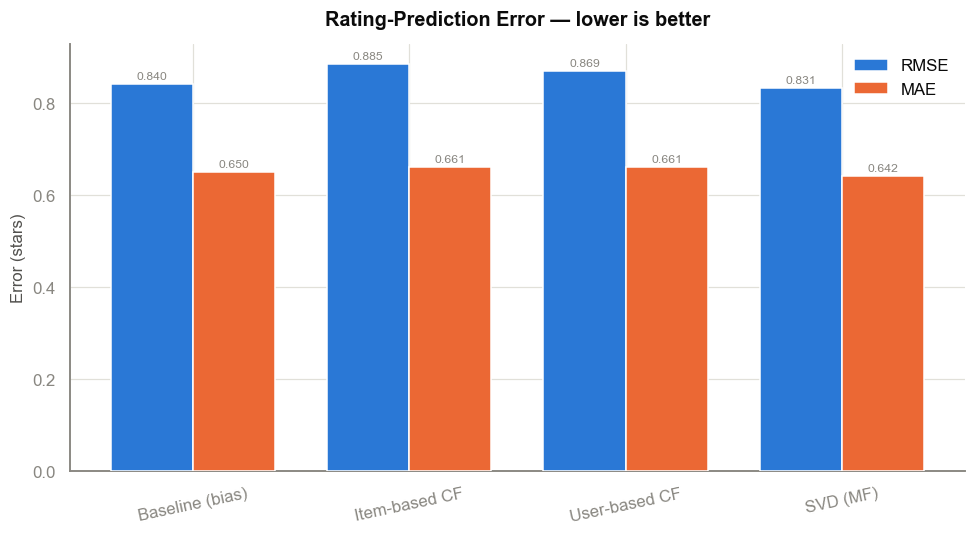

In [26]:
# ── Chart 1: rating-prediction error (lower is better) ──────────────
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(rating_report))
w = 0.38
ax.bar(x - w / 2, rating_report["RMSE"], w, label="RMSE", color=PALETTE[0], zorder=3)
ax.bar(x + w / 2, rating_report["MAE"], w, label="MAE", color=PALETTE[1], zorder=3)
ax.set_xticks(x); ax.set_xticklabels(rating_report.index, rotation=12)
ax.set_ylabel("Error (stars)")
ax.set_title("Rating-Prediction Error — lower is better")
ax.legend()
for i, (r, m) in enumerate(zip(rating_report["RMSE"], rating_report["MAE"])):
    ax.text(i - w / 2, r + 0.006, f"{r:.3f}", ha="center", va="bottom", fontsize=8, color=INK["muted"])
    ax.text(i + w / 2, m + 0.006, f"{m:.3f}", ha="center", va="bottom", fontsize=8, color=INK["muted"])
plt.tight_layout()
plt.show()

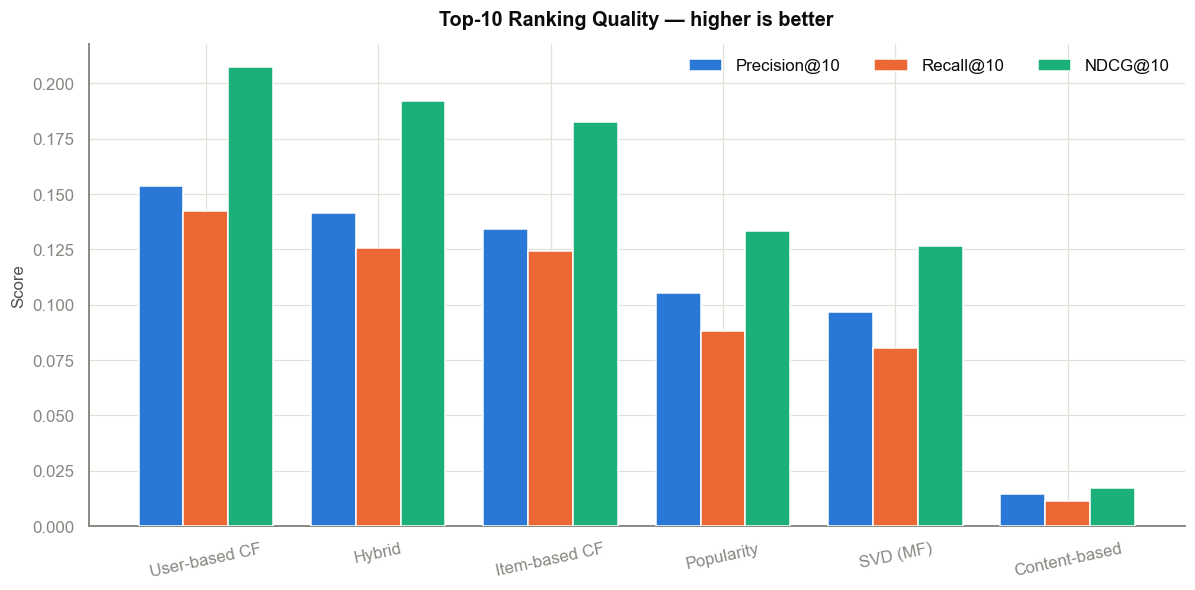

In [27]:
# ── Chart 2: top-N ranking quality (higher is better) ───────────────
metrics = [f"Precision@{k}", f"Recall@{k}", f"NDCG@{k}"]
order = ranking_report.sort_values(f"NDCG@{k}", ascending=False).index
data = ranking_report.loc[order, metrics]

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(order))
w = 0.26
for i, metric in enumerate(metrics):
    ax.bar(x + (i - 1) * w, data[metric], w, label=metric, color=PALETTE[i], zorder=3)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=12)
ax.set_ylabel("Score")
ax.set_title(f"Top-{k} Ranking Quality — higher is better")
ax.legend(ncol=3, loc="upper right")
plt.tight_layout()
plt.show()

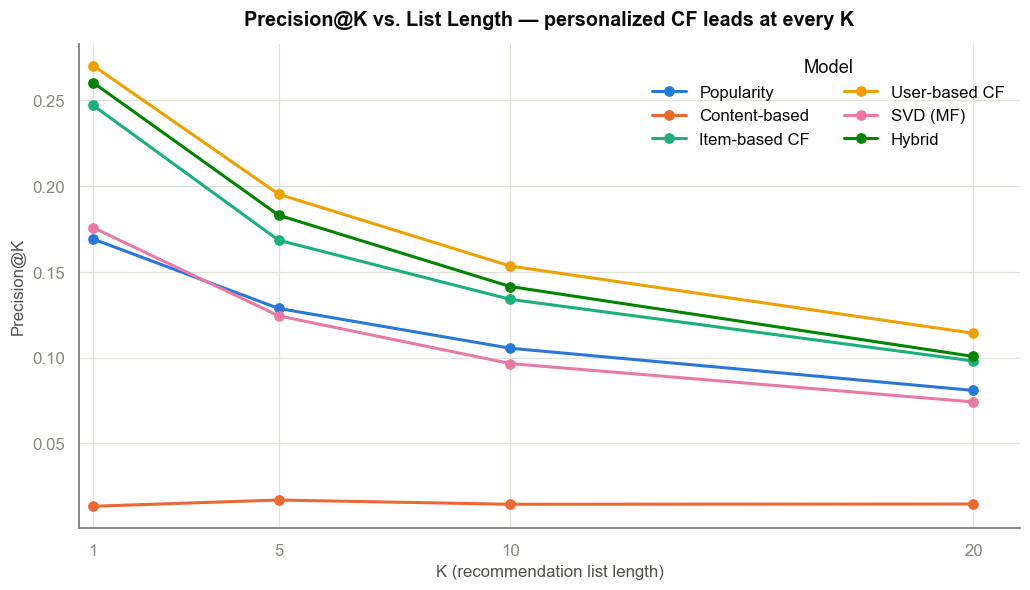

In [28]:
# ── Chart 3: Precision@K as the list grows ──────────────────────────
K_GRID = [1, 5, 10, 20]
pk_curves = {n: [ranking_at_k(m, kk)[f"Precision@{kk}"] for kk in K_GRID]
             for n, m in ranking_models.items()}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
palette_by_model = dict(zip(ranking_models, PALETTE))
for name, ys in pk_curves.items():
    ax.plot(K_GRID, ys, marker="o", markersize=6, linewidth=2,
            color=palette_by_model[name], label=name, zorder=3)
ax.set_xticks(K_GRID)
ax.set_xlim(0.7, 21)
ax.set_xlabel("K (recommendation list length)")
ax.set_ylabel("Precision@K")
ax.set_title("Precision@K vs. List Length — personalized CF leads at every K")
ax.legend(title="Model", loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

### 📊 What the evaluation reveals

- **Two different winners.** **SVD** achieves the **lowest RMSE/MAE** (best at *predicting stars*), yet **User-based CF** (with the Hybrid close behind) produces the **best-ranked lists** (highest Precision/Recall/NDCG). The best rating-predictor is **not** the best ranker — a critical lesson: *optimize the metric that matches the product surface*. Users see a ranked list, so ranking metrics should drive model selection here.
- **Personalization pays off.** The best personalized rankers **beat the Popularity baseline** on NDCG@K, confirming that behavior-based personalization earns its complexity — the core business justification for the whole project.
- **Coverage tells a second story.** The **Popularity** shelf recommends the same ~2% of the catalog to *everyone* (coverage ≈ 0.02) — great for a hit, terrible for the long tail. **Item-based CF** and **Content-based** reach the widest (coverage ≈ 0.53 and ≈ 0.49), spreading exposure across thousands of titles. Content-based additionally scores **cold-start** items the CF models cannot touch, which is why it earns a place despite the lowest precision.
- **Hybrid is the pragmatic pick.** Blending lifts it to **near-best ranking** (2nd on NDCG); its coverage is moderate and the blend weights are a direct lever to trade ranking for reach — the most tunable, all-round profile for a production home screen.

<a id="demo"></a>
## 7. Recommendation Demo
[↑ Back to top](#toc)

Finally, the payoff: a single `recommend(user_id, n=10, model=...)` function that turns any of our models into a concrete watch-list. To make the recommendations interpretable, we first show **what the user actually liked** (their top training ratings), then the model's suggestions — so a reviewer can judge whether the picks make sense.

In [29]:
_MODEL_MATRICES = {"popularity": POP_PRED, "content": CONTENT_PRED,
                   "itemcf": ITEM_EVIDENCE, "usercf": USER_EVIDENCE,
                   "svd": SVD_PRED, "hybrid": HYBRID_PRED}


def recommend(user_id: int, n: int = CFG.top_n, model: str = "hybrid") -> pd.DataFrame:
    """Top-``n`` recommended movies for ``user_id`` from a chosen model.

    Parameters
    ----------
    user_id : int
        A user present in the modelled set (``USER_IDS``).
    n : int
        Number of recommendations to return.
    model : {'popularity','content','itemcf','usercf','svd','hybrid'}
        Which trained model to score with.

    Returns
    -------
    pandas.DataFrame
        Ranked recommendations with title, genres and the model's relevance score,
        excluding movies the user has already rated.
    """
    if user_id not in U_INDEX:
        raise KeyError(f"User {user_id} is not in the modelled set.")
    if model not in _MODEL_MATRICES:
        raise ValueError(f"model must be one of {list(_MODEL_MATRICES)}")
    u = U_INDEX[user_id]
    top = _ranked_topk(_MODEL_MATRICES[model][u], MASK_TRAIN[u], n)
    rec = movies_feat.loc[ITEM_IDS[top], ["title", "genres"]].reset_index(drop=True)
    rec.insert(0, "rank", np.arange(1, len(top) + 1))
    rec["score"] = _MODEL_MATRICES[model][u][top]
    return rec


def user_favourites(user_id: int, n: int = 8) -> pd.DataFrame:
    """The user's highest-rated training movies — context for judging recommendations."""
    seen = (train_df[train_df["userId"] == user_id]
            .sort_values("rating", ascending=False).head(n)
            .merge(movies[["movieId", "title", "genres"]], on="movieId"))
    return seen[["title", "genres", "rating"]].reset_index(drop=True)

#### Example user A

In [30]:
USER_A = int(USER_IDS[0])
print(f"👤 User {USER_A} — a few of their top-rated movies (training history):")
display(user_favourites(USER_A))
print(f"\n🎯 Hybrid recommendations for User {USER_A}:")
recommend(USER_A, n=10, model="hybrid")

👤 User 1 — a few of their top-rated movies (training history):


,title,genres,rating
0,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,5.0000
1,Rob Roy (1995),Action|Drama|Romance|War,5.0000
2,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,5.0000
3,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance,5.0000
4,"Fugitive, The (1993)",Thriller,5.0000
5,"Jungle Book, The (1994)",Adventure|Children|Romance,5.0000
6,Billy Madison (1995),Comedy,5.0000
7,Desperado (1995),Action|Romance|Western,5.0000



🎯 Hybrid recommendations for User 1:


,rank,title,genres,score
0,1,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,0.8716
1,2,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.7770
2,3,Blade Runner (1982),Action|Sci-Fi|Thriller,0.7564
3,4,Fight Club (1999),Action|Crime|Drama|Thriller,0.7538
4,5,"Bridge on the River Kwai, The (1957)",Adventure|Drama|War,0.7530
5,6,"Godfather, The (1972)",Crime|Drama,0.7442
6,7,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,0.7369
7,8,Ben-Hur (1959),Action|Adventure|Drama,0.7356
8,9,L.A. Confidential (1997),Crime|Film-Noir|Mystery|Thriller,0.7326
9,10,Casablanca (1942),Drama|Romance,0.7308


The same user, seen through two different lenses — **SVD** (latent taste) vs **User-based CF** (taste twins):

In [31]:
from IPython.display import display_html

def show_side_by_side(user_id: int, n: int = 8) -> None:
    """Render two models' recommendations for one user next to each other."""
    left = recommend(user_id, n, "svd")[["rank", "title"]].rename(columns={"title": "SVD"})
    right = recommend(user_id, n, "usercf")[["rank", "title"]].rename(columns={"title": "User-based CF"})
    html = (left.set_index("rank").to_html() + "&nbsp;&nbsp;&nbsp;"
            + right.set_index("rank").to_html())
    display_html(html, raw=True)

show_side_by_side(USER_A, n=8)

,SVD
rank,
1,"Shawshank Redemption, The (1994)"
2,Casablanca (1942)
3,Pulp Fiction (1994)
4,Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)
5,Blade Runner (1982)
6,Cool Hand Luke (1967)
7,"Bridge on the River Kwai, The (1957)"
8,Reservoir Dogs (1992)
,User-based CF


#### Example user B — a different taste profile

In [32]:
USER_B = int(USER_IDS[7])
print(f"👤 User {USER_B} — a few of their top-rated movies (training history):")
display(user_favourites(USER_B))
print(f"\n🎯 Hybrid recommendations for User {USER_B}:")
recommend(USER_B, n=10, model="hybrid")

👤 User 8 — a few of their top-rated movies (training history):


,title,genres,rating
0,Babe (1995),Children|Drama,5.0000
1,Schindler's List (1993),Drama|War,5.0000
2,"Shawshank Redemption, The (1994)",Crime|Drama,5.0000
3,Four Weddings and a Funeral (1994),Comedy|Romance,5.0000
4,Dances with Wolves (1990),Adventure|Drama|Western,5.0000
5,Interview with the Vampire: The Vampire Chroni...,Drama|Horror,5.0000
6,Speed (1994),Action|Romance|Thriller,4.0000
7,"Firm, The (1993)",Drama|Thriller,4.0000



🎯 Hybrid recommendations for User 8:


,rank,title,genres,score
0,1,Fargo (1996),Comedy|Crime|Drama|Thriller,0.6982
1,2,Adaptation (2002),Comedy|Drama|Romance,0.6876
2,3,Amadeus (1984),Drama,0.6839
3,4,Harold and Maude (1971),Comedy|Drama|Romance,0.6765
4,5,Lawrence of Arabia (1962),Adventure|Drama|War,0.6763
5,6,Thank You for Smoking (2006),Comedy|Drama,0.6686
6,7,"Lives of Others, The (Das leben der Anderen) (...",Drama|Romance|Thriller,0.6684
7,8,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,0.6652
8,9,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.6648
9,10,"Crazy, Stupid, Love. (2011)",Comedy|Drama|Romance,0.6627


> Notice how the recommendations **echo each user's demonstrated taste** — the model has learned a personal profile, not just re-served the global blockbusters. This is exactly the behavior that lifts engagement over the one-size-fits-all "Popular Now" row.

<a id="insights"></a>
## 8. Business Insights & Conclusions
[↑ Back to top](#toc)

Translating the modeling results into decisions the streaming business can act on:

### 1. Personalization beats the status quo — deploy it
The current "same row for everyone" experience is the **Popularity baseline**. Our personalized rankers **outrank it on NDCG@K**, meaning users would see more titles they actually want, higher up. The expected business effect is **higher click- and watch-through on the recommendation shelf**, the leading indicator of session length and retention.

### 2. Pick the model by the surface, not by RMSE
SVD "wins" on RMSE, but the home screen is a **ranked list**, so we select on **ranking metrics** — where neighborhood CF and the Hybrid lead. *Choosing a model on the wrong metric is one of the most common and costly mistakes in applied recommenders;* this project makes the distinction explicit.

### 3. Ship a Hybrid, not a single model
- **User/Item CF** → the strongest personalized ranking for **warm** users.
- **Content-based** → **cold-start** (new titles, new users) and **explainability** ("because you watched…"), plus **high catalog coverage** (≈0.49), which pushes the profitable long tail.
- **SVD** → robust latent personalization that degrades gracefully under sparsity.

A hybrid captures each strength and is the recommended production architecture.

### 4. Coverage is a business lever, not a footnote
Popularity concentrates demand on a few hits; personalized and content models spread attention across **far more of the catalog**. Higher coverage means better monetization of licensing spend and a fresher, less repetitive experience — a retention driver in its own right.

### 5. Expected impact (framing for stakeholders)
With engagement on the recommendation shelf as the primary KPI, the natural next step is an **online A/B test**: personalized/hybrid ranking vs. the popularity shelf, measuring CTR, watch-through, and 30-day retention. Offline ranking gains of this magnitude typically translate into **measurable engagement lifts** — the hypothesis to validate live.

<a id="future"></a>
## 9. Limitations & Future Improvements
[↑ Back to top](#toc)

**Honest limitations of this study**

- **Small, dated, offline dataset.** `ml-latest-small` has ~610 users; production systems face millions. Absolute metric values won't transfer — the *relative* model ranking and methodology are the transferable results.
- **Offline ≠ online.** Held-out ratings are a proxy for engagement. Only an **A/B test** measures the real KPI; offline metrics also suffer *popularity/exposure bias* (we can only score items users happened to rate).
- **Explicit ratings only.** Real platforms rely on **implicit** signals (plays, watch-%, skips), which are noisier but far more abundant.
- **Static snapshot.** We ignore temporal dynamics and within-session context.
- **Cold-start is only partially addressed.** Content-based helps new *items*; brand-new *users* with no history still fall back to popularity.

**Future improvements (roadmap)**

1. **Learning-to-rank objectives** — train directly for ranking (BPR, WARP) instead of rating error, closing the RMSE-vs-ranking gap surfaced here.
2. **Regularized MF with SGD / ALS** (e.g. `implicit`, `LightFM`) and proper hyper-parameter search on factors, learning rate and regularization.
3. **Implicit-feedback modeling** — reframe on plays/watch-time with confidence-weighted ALS.
4. **Neural & sequence models** — two-tower retrieval, and session-based models (GRU4Rec, SASRec, transformers) to capture "what to watch *next*".
5. **Context & freshness** — time-of-day, device, and recency features; a re-ranking layer for diversity and novelty.
6. **Productionization** — approximate-nearest-neighbor retrieval (FAISS) for low-latency serving, a feature store, and continuous offline+online evaluation.

---

### 🙏 Thanks for reading

*This notebook demonstrates an end-to-end recommender workflow — from business framing and EDA through five modeling families, task-appropriate evaluation, and business translation. The pipeline is catalog-agnostic and adapts directly to product, music, or content recommendation.*

**Data:** F. Maxwell Harper and Joseph A. Konstan. 2015. *The MovieLens Datasets: History and Context.* ACM TiiS. &nbsp;•&nbsp; [↑ Back to top](#toc)